# Sachs dataset: PC, k-PC, Cluster-PC, FCI, Cluster-FCI, and FCI-Tiers

This notebook applies six causal discovery algorithms on the Sachs dataset and plots the Sachs ground-truth graph after each run.

Data shape: (7466, 11)
Node names: ['praf', 'pmek', 'plcg', 'PIP2', 'PIP3', 'p44/42', 'pakts473', 'PKA', 'PKC', 'P38', 'pjnk']


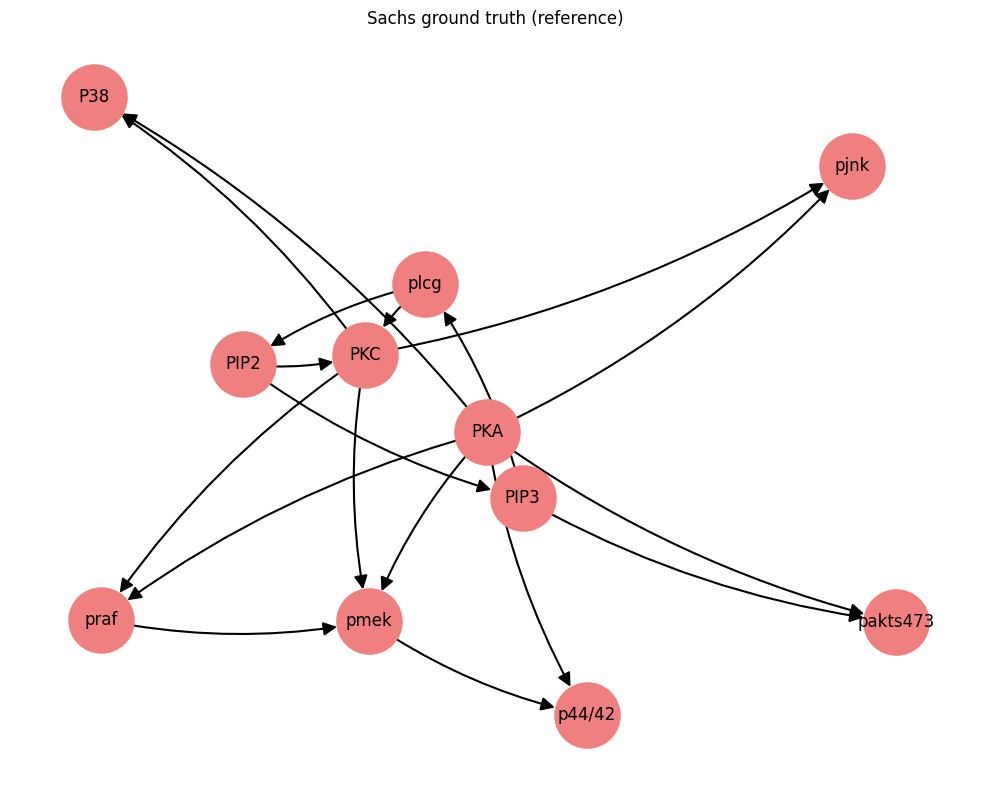

In [20]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import networkx as nx

from cdt.data import load_dataset
from causallearn.graph.GraphClass import CausalGraph
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci

from clustercausal.algorithms.kPC import kpc
from clustercausal.algorithms.ClusterPC import ClusterPC
from clustercausal.algorithms.ClusterFCI import ClusterFCI
from clustercausal.algorithms.FCITiers import fci_tiers
from clustercausal.clusterdag.ClusterDAG import ClusterDAG

# Load Sachs data and ground truth graph
data, ground_truth = load_dataset("sachs")
node_names = data.columns.tolist()
X = data.to_numpy()

print(f"Data shape: {X.shape}")
print(f"Node names: {node_names}")

def plot_ground_truth_graph(title="Sachs ground truth"):
    fig, ax = plt.subplots(figsize=(10, 8))
    pos = nx.spring_layout(ground_truth, seed=42, k=0.75)
    nx.draw(
        ground_truth,
        pos,
        ax=ax,
        with_labels=True,
        node_size=2200,
        node_color="lightcoral",
        arrowstyle='-|>',
        arrowsize=20,
        width=1.5,
        connectionstyle='arc3,rad=0.1',
    )
    ax.set_title(title)
    ax.axis("off")
    plt.show()

plot_ground_truth_graph("Sachs ground truth (reference)")

In [21]:
# Build tiers from the Sachs graph to create a compatible ClusterDAG
check_graph = ground_truth.copy()

if nx.is_directed_acyclic_graph(check_graph):
    topo_generations = [list(gen) for gen in nx.topological_generations(check_graph)]
    node_to_tier = {
        node: idx + 1
        for idx, generation in enumerate(topo_generations)
        for node in generation
    }
else:
    scc_graph = nx.condensation(check_graph)
    topo_scc_generations = [list(gen) for gen in nx.topological_generations(scc_graph)]
    node_to_tier = {}
    for idx, scc_generation in enumerate(topo_scc_generations):
        for scc_node in scc_generation:
            for node in scc_graph.nodes[scc_node]["members"]:
                node_to_tier[node] = idx + 1
    print("Ground-truth graph has cycles; tiers were built from SCC condensation.")

# Keep node order consistent with data columns
cluster_mapping = {}
for tier_idx in sorted(set(node_to_tier.values())):
    tier_nodes = [node for node in node_names if node_to_tier.get(node) == tier_idx]
    if tier_nodes:
        cluster_mapping[f"C{tier_idx}"] = tier_nodes

# Fully ordered tier edges C_i -> C_j for i < j
cluster_names = list(cluster_mapping.keys())
cluster_edges = [
    (cluster_names[i], cluster_names[j])
    for i in range(len(cluster_names))
    for j in range(i + 1, len(cluster_names))
]

def make_sachs_cluster_dag():
    return ClusterDAG(
        cluster_mapping=cluster_mapping,
        cluster_edges=cluster_edges,
        node_names=node_names,
    )

print("Cluster mapping used for cluster-based methods:")
for cluster_name, members in cluster_mapping.items():
    print(f"  {cluster_name}: {members}")
print(f"Cluster edges: {cluster_edges}")

Ground-truth graph has cycles; tiers were built from SCC condensation.
Cluster mapping used for cluster-based methods:
  C1: ['plcg', 'PIP2', 'PIP3', 'PKA']
  C2: ['pakts473', 'PKC']
  C3: ['praf', 'P38', 'pjnk']
  C4: ['pmek']
  C5: ['p44/42']
Cluster edges: [('C1', 'C2'), ('C1', 'C3'), ('C1', 'C4'), ('C1', 'C5'), ('C2', 'C3'), ('C2', 'C4'), ('C2', 'C5'), ('C3', 'C4'), ('C3', 'C5'), ('C4', 'C5')]


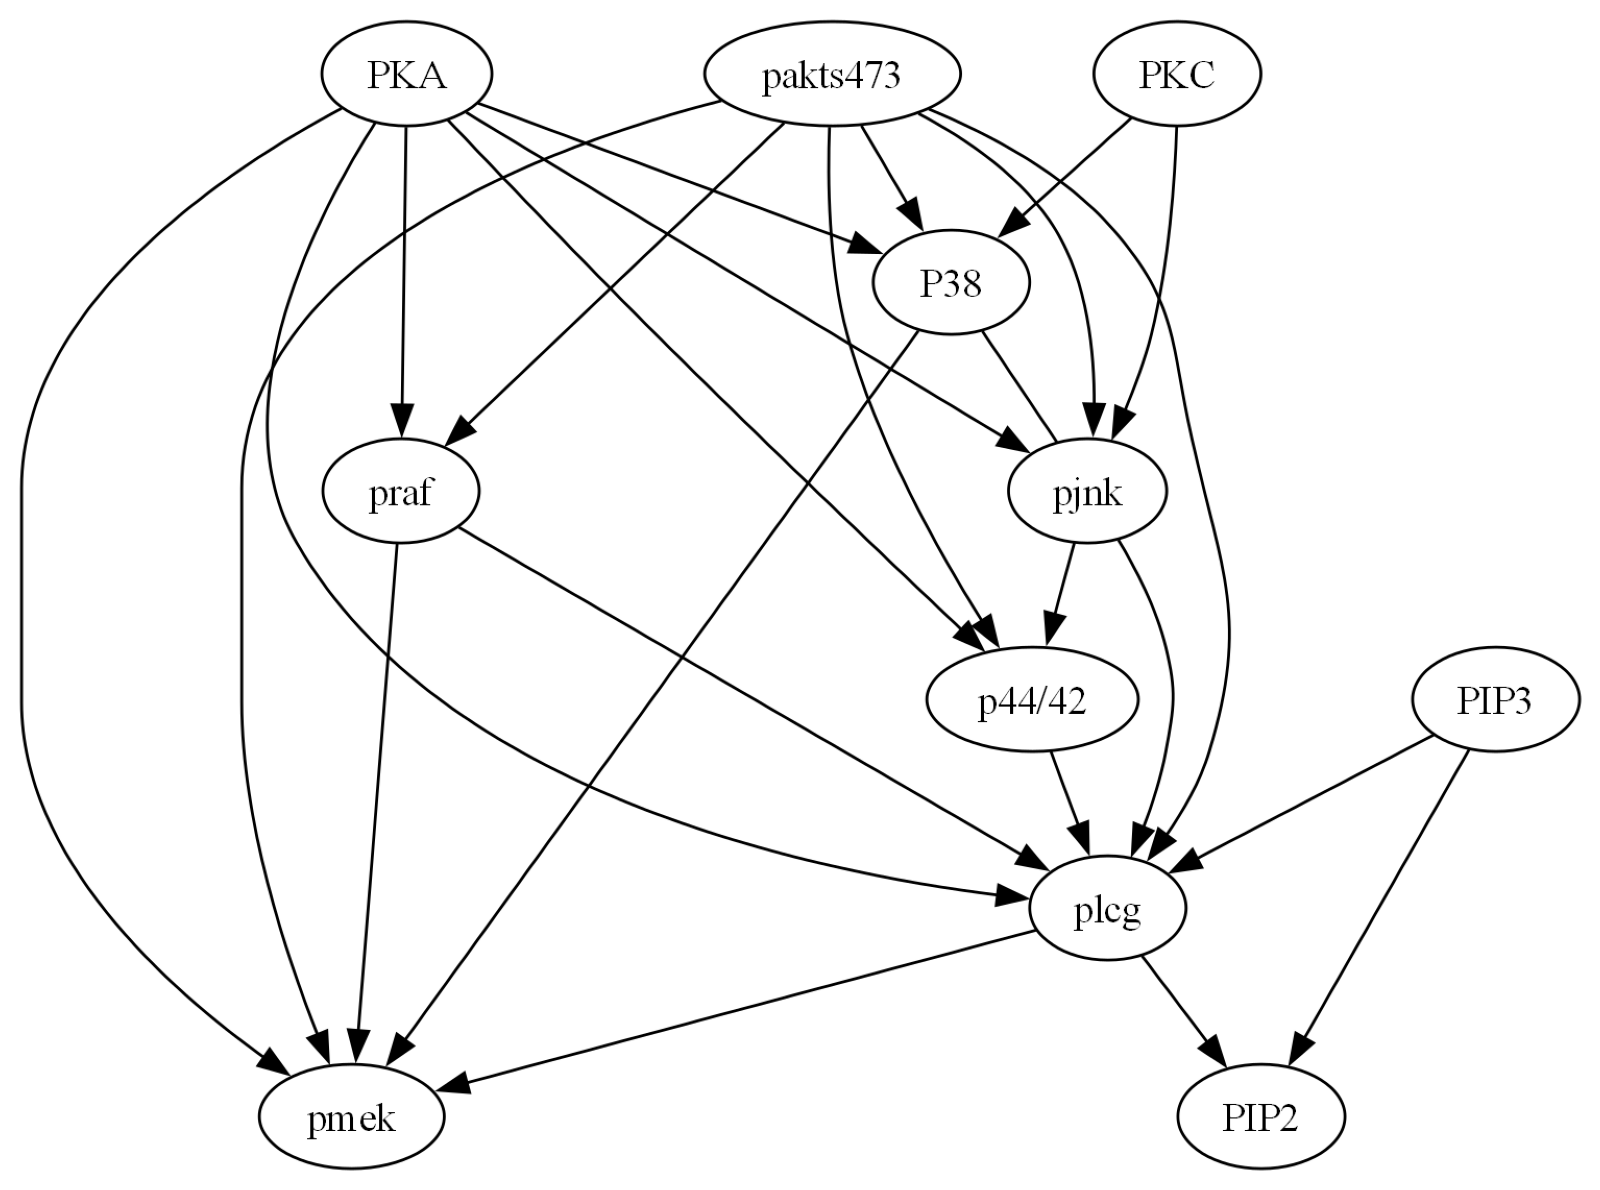

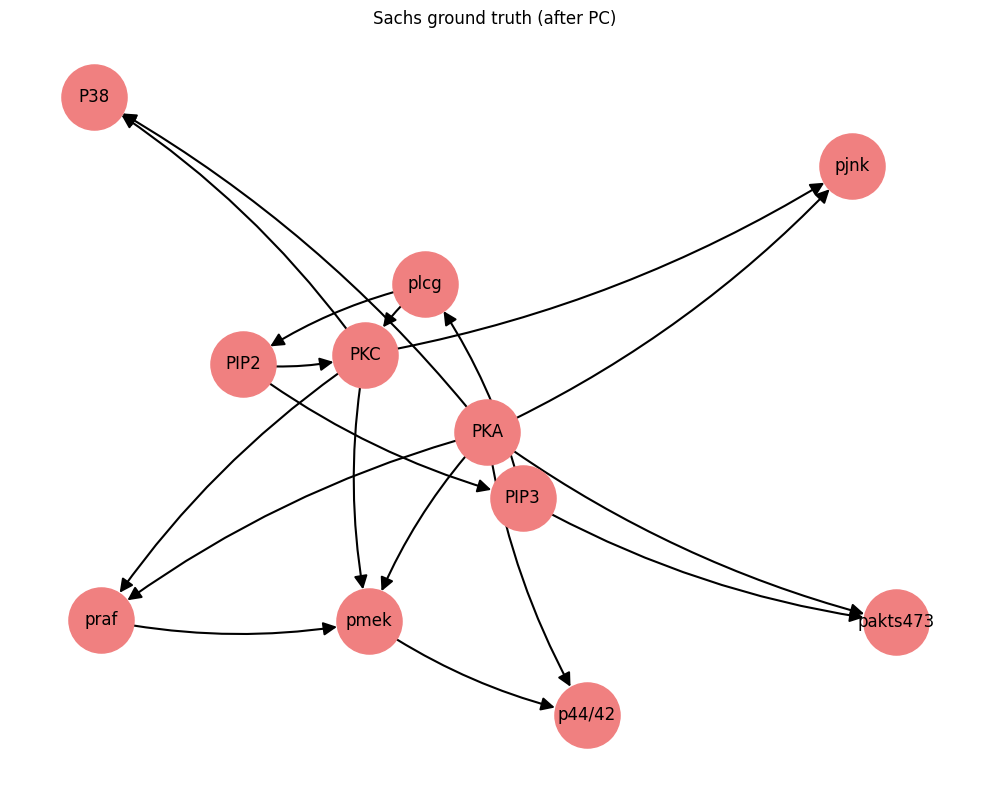

In [22]:
# PC
pc_est_graph = pc(X, alpha=0.05, verbose=False, show_progress=False, node_names=node_names)
pc_est_graph.draw_pydot_graph()
plot_ground_truth_graph("Sachs ground truth (after PC)")

## k-PC

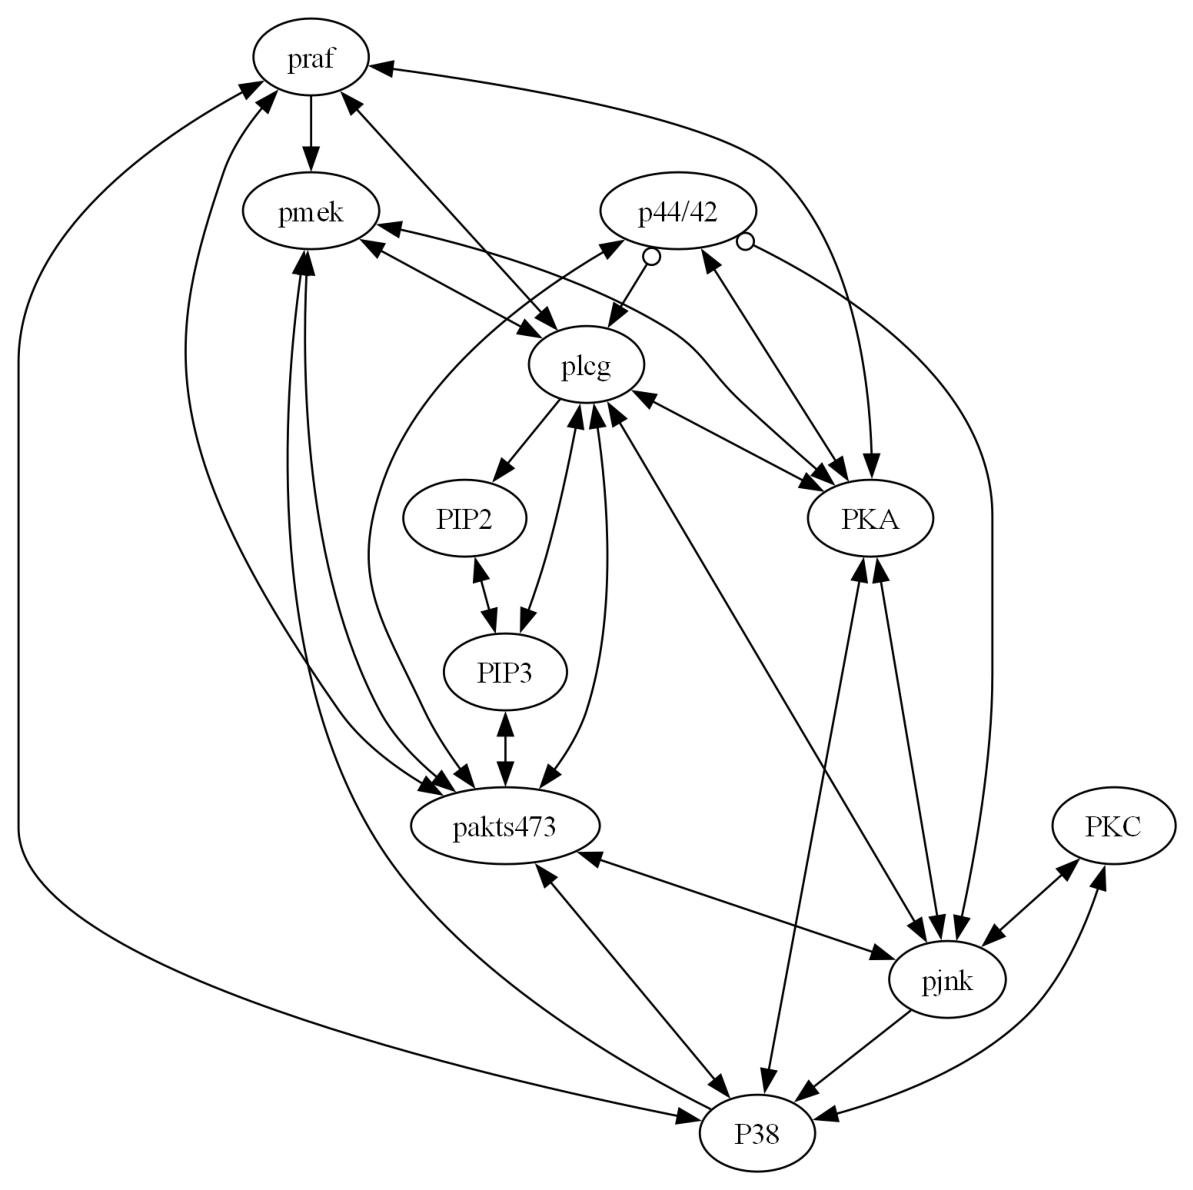

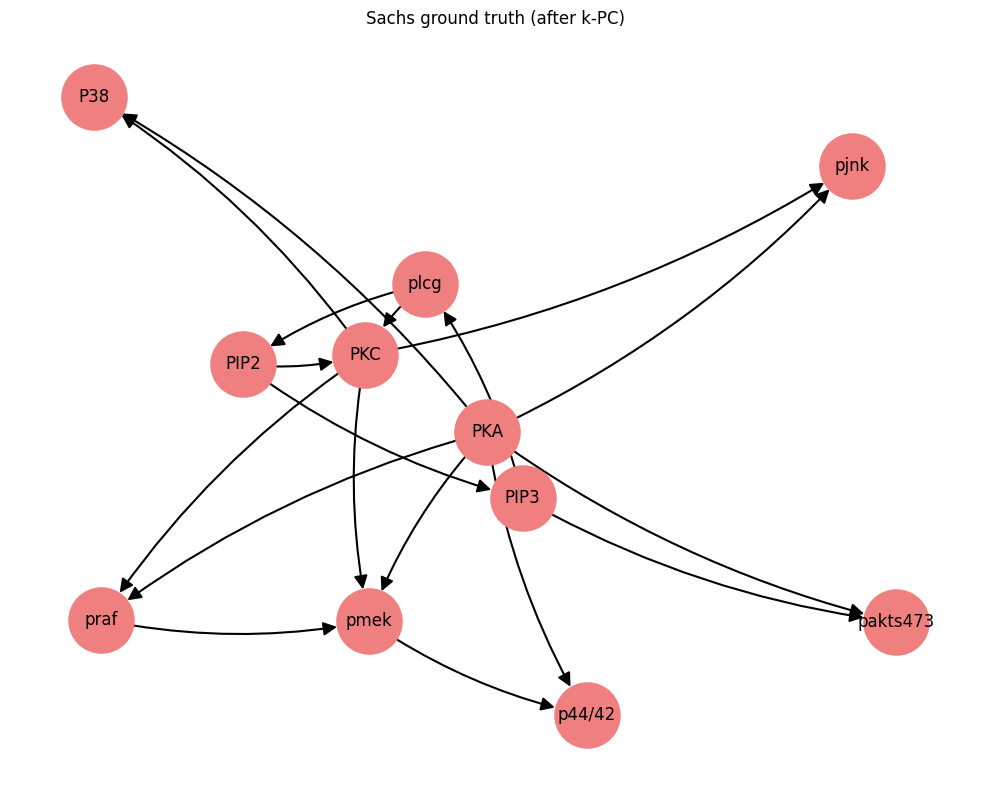

In [23]:
k = 2
kpc_est_graph = kpc(
    X,
    k=k,
    alpha=0.05,
    verbose=False,
    show_progress=False,
    node_names=node_names,
    indep_test="fisherz",
)
kpc_est_graph.draw_pydot_graph()
plot_ground_truth_graph("Sachs ground truth (after k-PC)")

## Cluster-PC

Duration of algorithm was 0.07sec


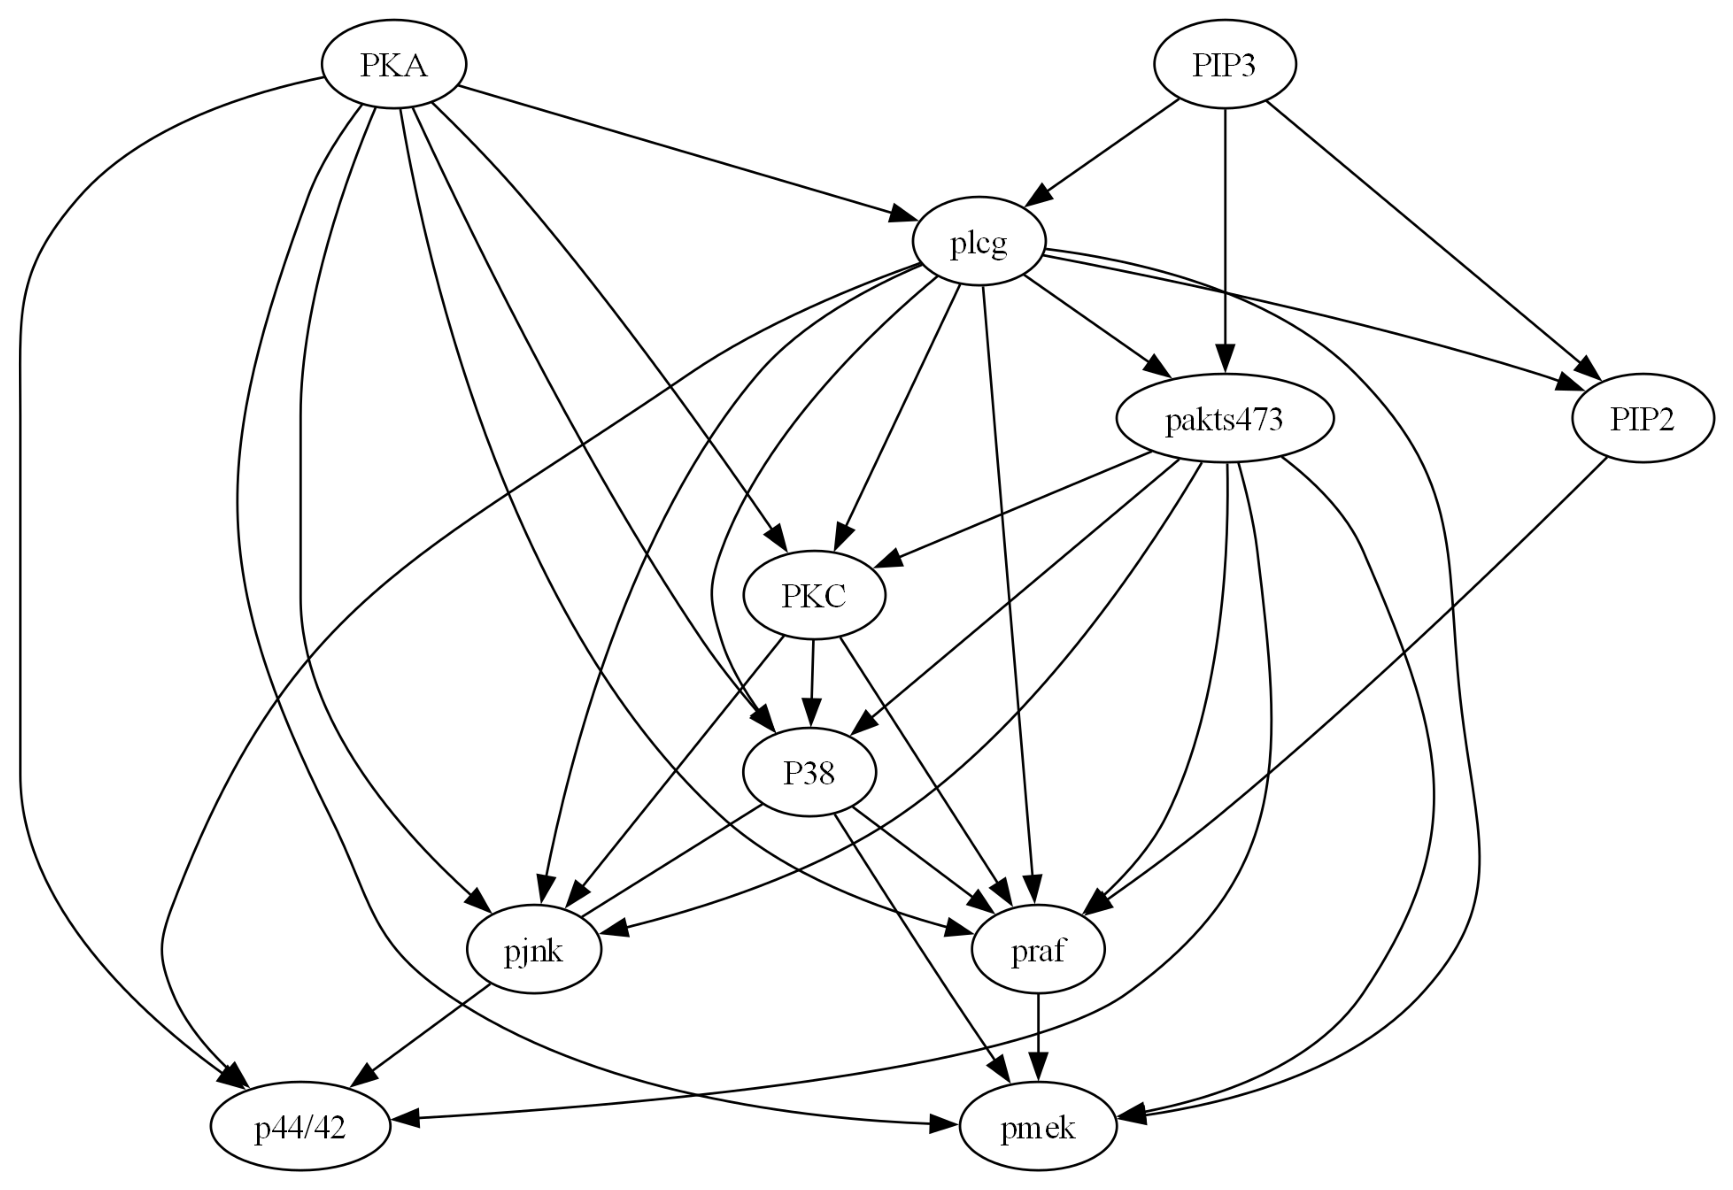

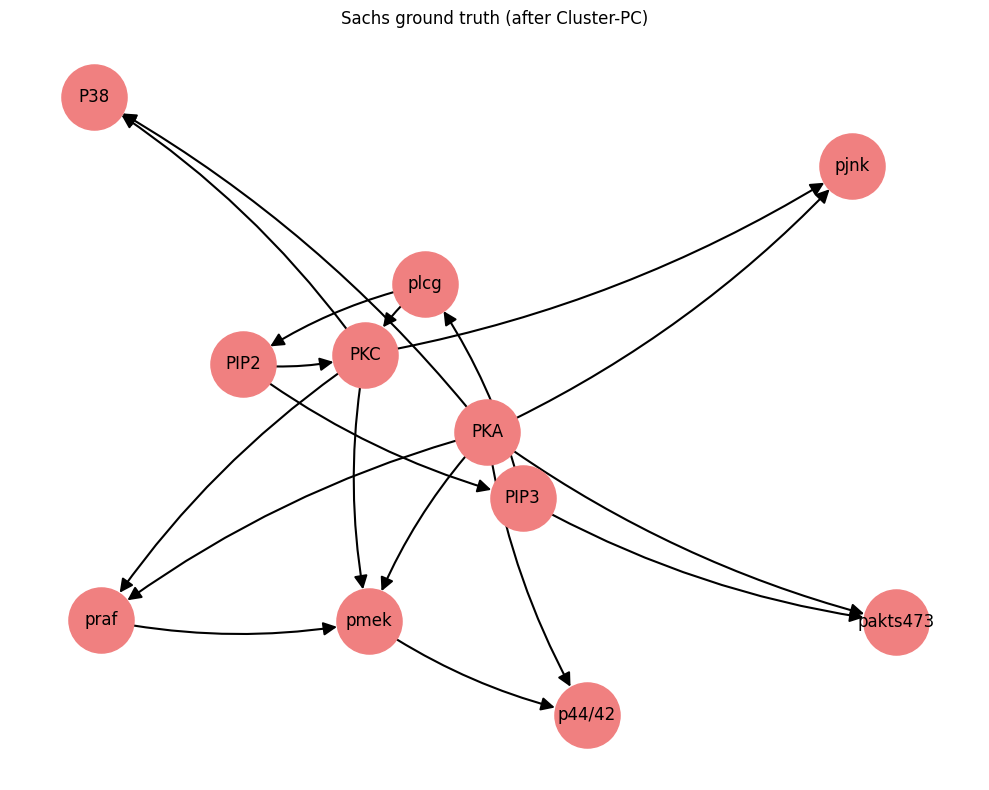

In [24]:
cluster_dag_pc = make_sachs_cluster_dag()
cluster_pc = ClusterPC(
    cdag=cluster_dag_pc,
    data=X,
    alpha=0.05,
    indep_test="fisherz",
    verbose=False,
    show_progress=False,
    stable=True,
)
cluster_pc_est_graph = cluster_pc.run()
cluster_pc_est_graph.draw_pydot_graph()
plot_ground_truth_graph("Sachs ground truth (after Cluster-PC)")

In [25]:
# Evaluator comparison for PC variants (PC, k-PC, Cluster-PC)
import pandas as pd
from clustercausal.experiments.Evaluator import Evaluator
from clustercausal.utils.Utils import nx_to_causallearn_adjmat

truth_cg = CausalGraph(no_of_var=len(node_names), node_names=node_names)
truth_nx_adj = nx.to_numpy_array(ground_truth, nodelist=node_names, dtype=int)
truth_cg.G.graph = nx_to_causallearn_adjmat(truth_nx_adj)

pc_variant_graphs = {
    "PC": pc_est_graph,
    "k-PC": kpc_est_graph,
    "Cluster-PC": cluster_pc_est_graph,
}

rows = []
for method_name, est_cg in pc_variant_graphs.items():
    evaluator = Evaluator(truth=truth_cg.G, est=est_cg.G)
    adj_conf, arrow_conf, shd, _ = evaluator.get_causallearn_metrics(sid=False)
    rows.append(
        {
            "Method": method_name,
            "Adj. precision": adj_conf["precision"],
            "Adj. recall": adj_conf["recall"],
            "Adj. F1-score": adj_conf["f1_score"],
            "Arrow precision": arrow_conf["precision"],
            "Arrow recall": arrow_conf["recall"],
            "Arrow F1-score": arrow_conf["f1_score"],
            "SHD": shd,
        }
    )

pc_variant_eval = pd.DataFrame(rows).set_index("Method")
display(
    pc_variant_eval.style.format(
        {
            "Adj. precision": "{:.1%}",
            "Adj. recall": "{:.1%}",
            "Adj. F1-score": "{:.1%}",
            "Arrow precision": "{:.1%}",
            "Arrow recall": "{:.1%}",
            "Arrow F1-score": "{:.1%}",
            "SHD": "{:.1f}",
        }
    )
)

INFO: cffi mode is CFFI_MODE.ANY
INFO: R home found: C:\Program Files\R\R-4.3.1
INFO: Default options to initialize R: rpy2, --quiet, --no-save


,Adj. precision,Adj. recall,Adj. F1-score,Arrow precision,Arrow recall,Arrow F1-score,SHD
Method,,,,,,,
PC,44.0%,61.1%,51.2%,41.7%,55.6%,47.6%,22.0
k-PC,44.4%,66.7%,53.3%,25.0%,66.7%,36.4%,31.0
Cluster-PC,42.4%,77.8%,54.9%,40.6%,72.2%,52.0%,24.0


## FCI

Depth=7, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 2199.32it/s]


X3 --> X4
X7 --> X11


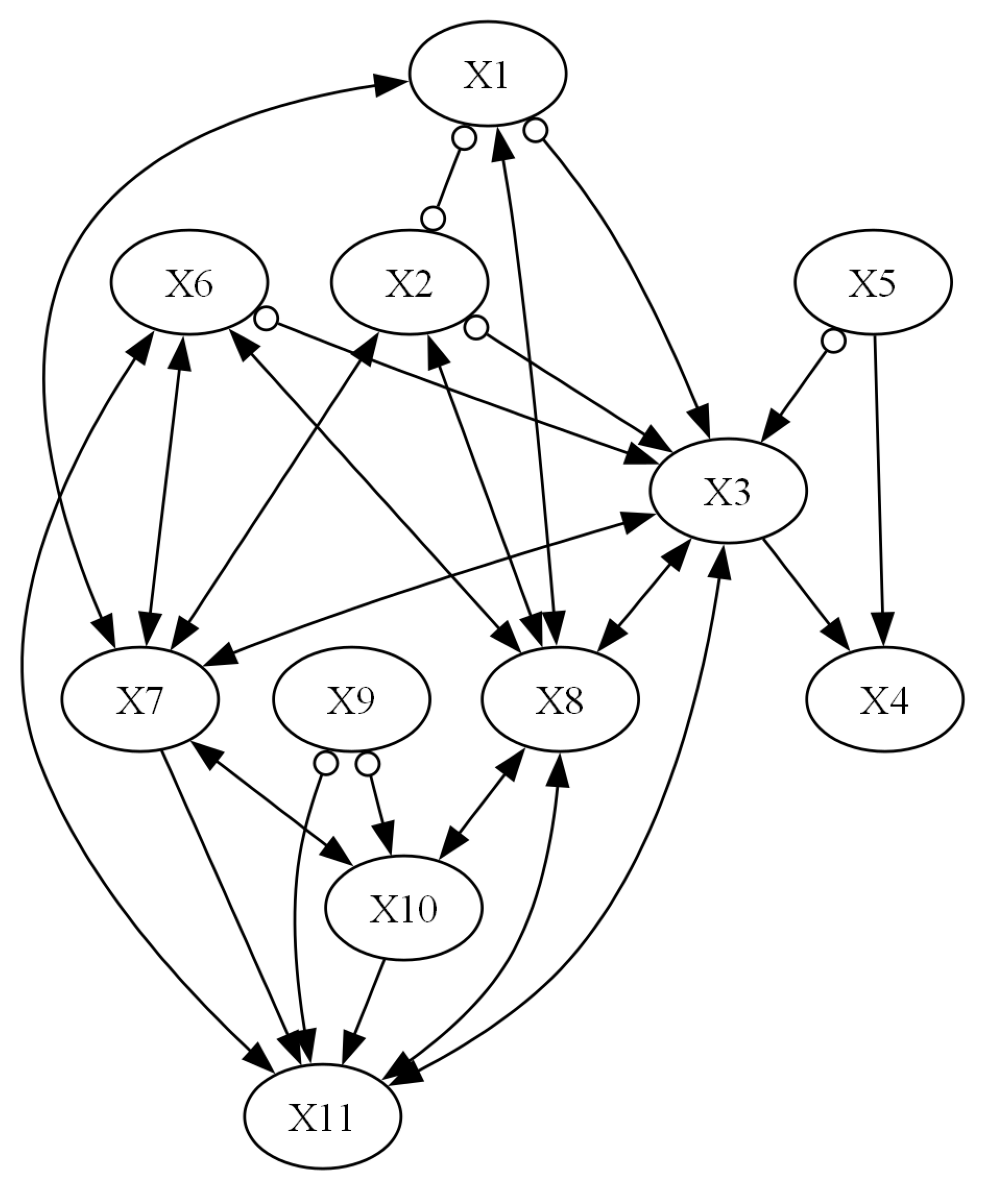

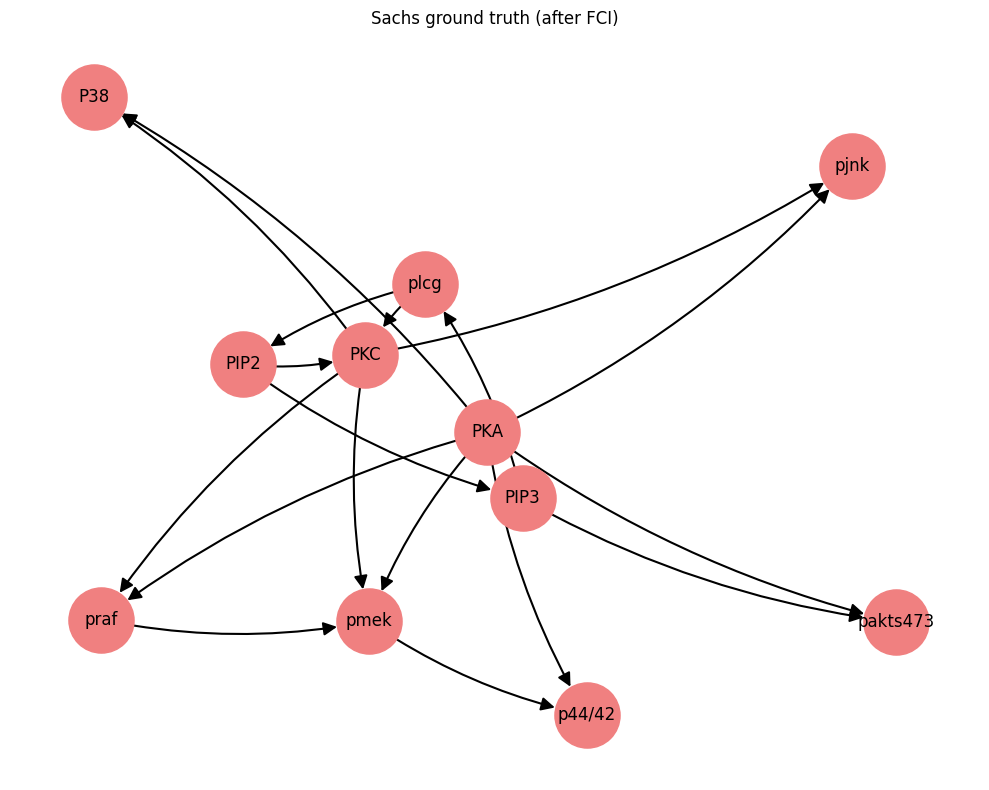

In [26]:
fci_graph, fci_edges = fci(
    X,
    alpha=0.05,
    verbose=False,
    show_progress=False,
)

# Wrap FCI result for consistent plotting API
fci_est_graph = CausalGraph(no_of_var=len(node_names), node_names=node_names)
fci_est_graph.G = fci_graph
fci_est_graph.draw_pydot_graph()
plot_ground_truth_graph("Sachs ground truth (after FCI)")

## Cluster-FCI

praf --> pmek
plcg --> praf
pakts473 --> praf
plcg --> pmek
pakts473 --> pmek
P38 --> pmek
plcg --> PIP2
plcg --> p44/42
plcg --> pakts473
plcg --> PKC
plcg --> P38
plcg --> pjnk
pakts473 --> p44/42
pjnk --> p44/42
pakts473 --> P38
pakts473 --> pjnk
PKC --> P38
PKC --> pjnk


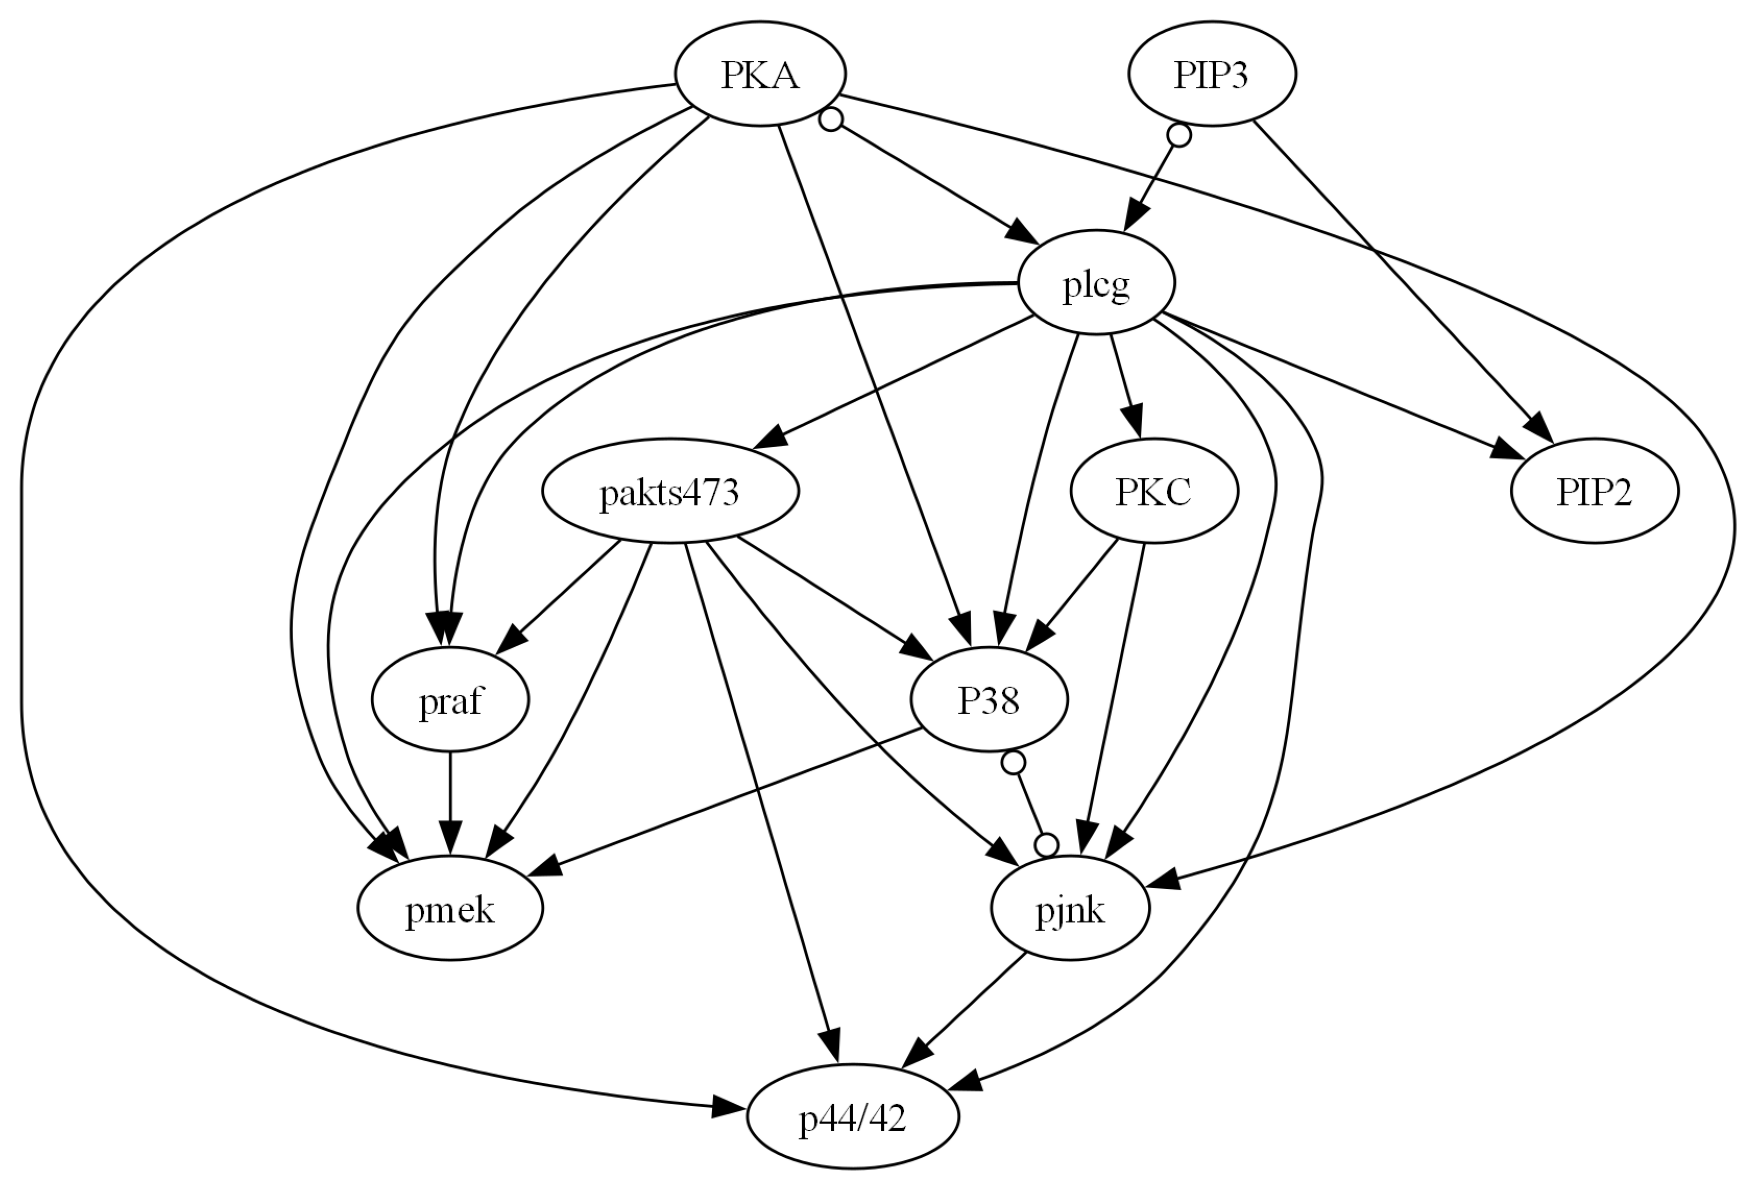

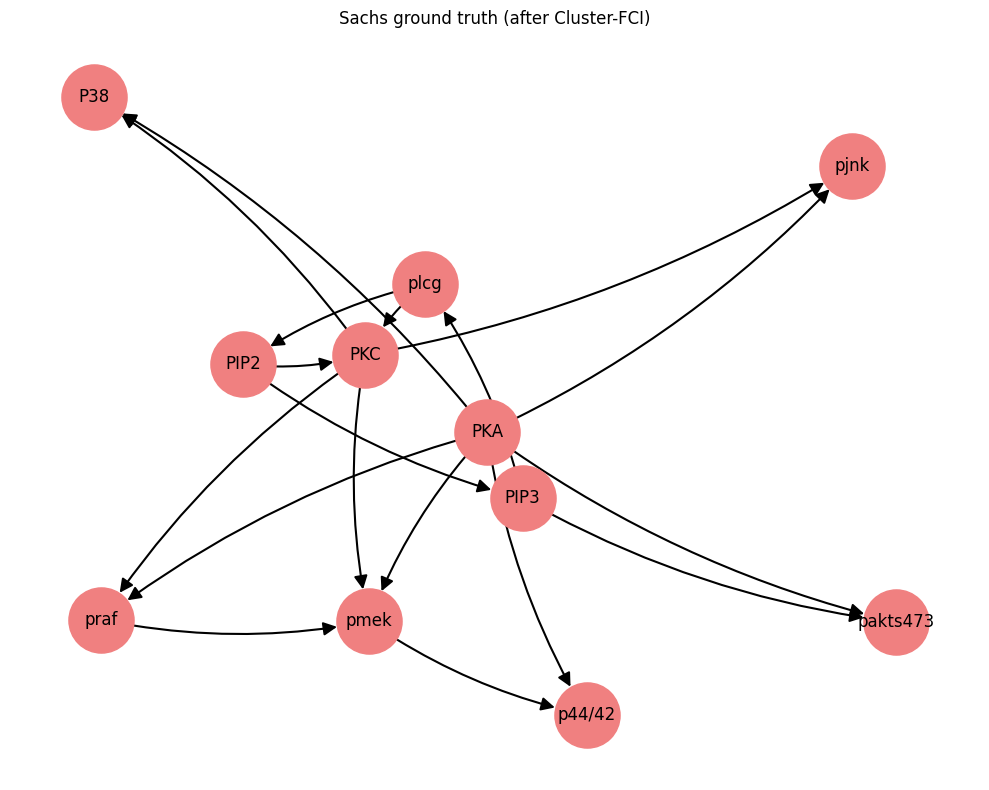

In [27]:
cluster_dag_fci = make_sachs_cluster_dag()
cluster_fci = ClusterFCI(
    cdag=cluster_dag_fci,
    dataset=X,
    alpha=0.05,
    verbose=False,
    show_progress=False,
)
cluster_fci_est_graph, cluster_fci_edges = cluster_fci.run()
cluster_fci_est_graph.draw_pydot_graph()
plot_ground_truth_graph("Sachs ground truth (after Cluster-FCI)")

## FCI-Tiers

In [28]:
cluster_dag_tiers = make_sachs_cluster_dag()
tiers = cluster_dag_tiers.get_cluster_topological_ordering()
fci_tiers_est_graph, fci_tiers_edges = fci_tiers(
    tiers=tiers,
    cluster_mapping=cluster_mapping,
    cdag=cluster_dag_tiers,
    dataset=X,
    alpha=0.05,
    verbose=False,
    show_progress=False,
)
fci_tiers_est_graph.draw_pydot_graph()
plot_ground_truth_graph("Sachs ground truth (after FCI-Tiers)")

AttributeError: 'ClusterDAG' object has no attribute 'cg'